In [1]:
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

In [2]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
# Nodes
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append(
            {"role": "system", "content": f"Conversation summary:\n{state['summary']}"}
        )

    messages.extend(state["messages"])

    print(messages)

    response = llm.invoke(messages)
    return {"messages": [response]}


def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]

    response = llm.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 5

In [6]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")
builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: END,
    },
)

builder.add_edge("summarize", END)

graph = builder.compile(checkpointer=InMemorySaver())

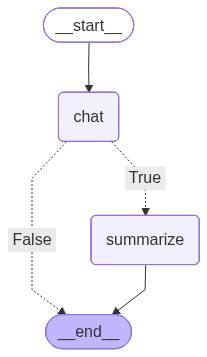

In [7]:
graph

In [8]:
config = {"configurable": {"thread_id": "t1"}}


def run_turn(text: str):
    out = graph.invoke(
        {"messages": [HumanMessage(content=text)], "summary": ""}, config=config
    )
    return out

In [9]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [10]:
run_turn("Quantum Physics")
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='987ac08c-2cad-4e6a-92b3-cbf0d29d6c20')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame


In [11]:
run_turn("Briefly explain, How is Albert Einstien related?")
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='987ac08c-2cad-4e6a-92b3-cbf0d29d6c20'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental theory in physics that provides a description of the physical properties of nature at the scale of atoms and subatomic particles. It\'s a revolutionary departure from classical physics, which describes the macroscopic world we experience.\n\nHere are some of the core concepts and ideas of quantum physics:\n\n**1. Quantization:**\n\n*   **Discrete Energy Levels:** Unlike classical physics where energy can take on any continuous value, in quantum mechanics, energy, momentum, angular momentum, and other properties of a system are often quantized. This means they can only exist in discrete, specific values. Think of it like stairs instead of a ramp – you can only be on a specific step, not in between.\n*   **Photons:** Light, for example, is quantized into pack

In [12]:
run_turn("List Einstien's top 5 work")
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='987ac08c-2cad-4e6a-92b3-cbf0d29d6c20'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental theory in physics that provides a description of the physical properties of nature at the scale of atoms and subatomic particles. It\'s a revolutionary departure from classical physics, which describes the macroscopic world we experience.\n\nHere are some of the core concepts and ideas of quantum physics:\n\n**1. Quantization:**\n\n*   **Discrete Energy Levels:** Unlike classical physics where energy can take on any continuous value, in quantum mechanics, energy, momentum, angular momentum, and other properties of a system are often quantized. This means they can only exist in discrete, specific values. Think of it like stairs instead of a ramp – you can only be on a specific step, not in between.\n*   **Photons:** Light, for example, is quantized into pack